In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/race_driver_labels.csv")

df.head()

,raceId,driverId,constructorId,grid,positionOrder,points,statusId,year,round,circuitId,...,avgPitDuration_ms,driverName_x,constructorName_x,driverName_y,constructorName_y,driverName,constructorName,finishPosition,avgLapTime_s,constructorPoints
0,18,1,1,1,1,10.0,1,2008,1,1,...,0.0,Lewis Hamilton,McLaren,Lewis Hamilton,McLaren,Lewis Hamilton,McLaren,1,98.114069,14.0
1,18,2,2,5,2,8.0,1,2008,1,1,...,0.0,Nick Heidfeld,BMW Sauber,Nick Heidfeld,BMW Sauber,Nick Heidfeld,BMW Sauber,2,98.208517,8.0
2,18,3,3,7,3,6.0,1,2008,1,1,...,0.0,Nico Rosberg,Williams,Nico Rosberg,Williams,Nico Rosberg,Williams,3,98.254810,9.0
3,18,4,4,11,4,5.0,1,2008,1,1,...,0.0,Fernando Alonso,Renault,Fernando Alonso,Renault,Fernando Alonso,Renault,4,98.410293,5.0
4,18,5,1,3,5,4.0,1,2008,1,1,...,0.0,Heikki Kovalainen,McLaren,Heikki Kovalainen,McLaren,Heikki Kovalainen,McLaren,5,98.424655,14.0


In [2]:
features = [
    "qualifyingPosition",
    "avgLapTime_s",
    "constructorPoints"
]

X = df[features]
y_finish = df["finishPosition"]

In [3]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_finish, test_size=0.2, random_state=42
)

In [5]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Finish Position — Linear Regression")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

Finish Position — Linear Regression
MAE: 5.57
RMSE: 6.79
R²: 0.224


Interpretation:
MAE ≈ On average, the model is off by X finishing positions
RMSE > MAE → occasional large errors (crashes, DNFs)
R² tells how much signal exists beyond randomness

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [8]:
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Finish Position — Random Forest")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²: {r2_rf:.3f}")

Finish Position — Random Forest
MAE: 4.92
RMSE: 6.22
R²: 0.347


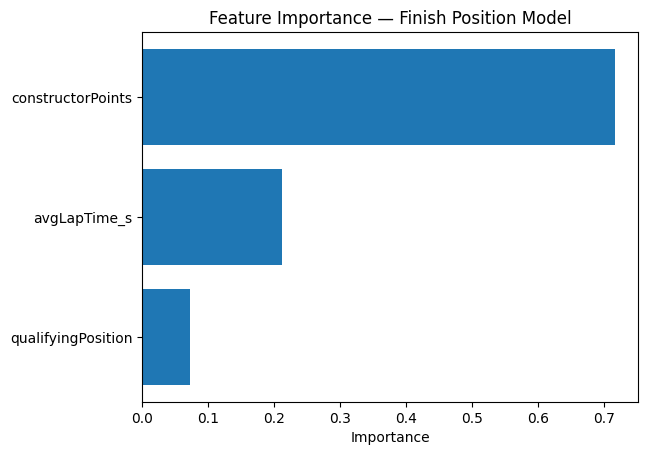

In [9]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
plt.barh(features, importances)
plt.title("Feature Importance — Finish Position Model")
plt.xlabel("Importance")
plt.show()